In [115]:
import cv2
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [116]:
# Load the elephant template image (object to detect)
box_image = cv2.imread("/home/nigus/EDU/Supervised/ImagesObjectDetection/elephant.jpg", cv2.IMREAD_GRAYSCALE)
# Load the cluttered desk image where we search for the elephant
scene_image = cv2.imread("/home/nigus/EDU/Supervised/ImagesObjectDetection/clutteredDesk.jpg", cv2.IMREAD_GRAYSCALE)

Number of polyline points: 19
[[ 33. 322.]
 [ 53.  95.]
 [209.  76.]
 [249.  46.]
 [279.  61.]
 [285.   8.]
 [348.  12.]
 [357.  64.]
 [338.  65.]
 [356. 172.]
 [328. 216.]
 [290. 219.]
 [343. 351.]
 [246. 348.]
 [235. 290.]
 [193. 356.]
 [ 97. 351.]
 [ 89. 330.]
 [ 31. 320.]]


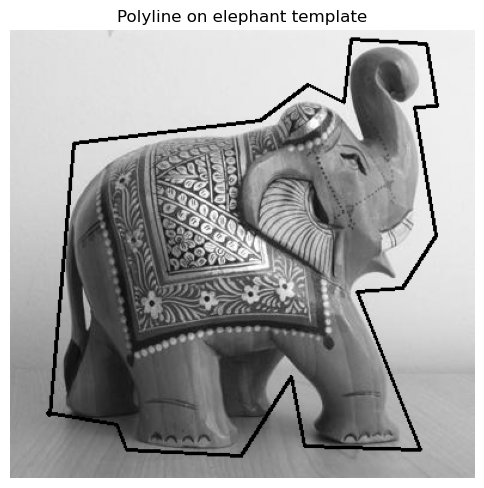

In [122]:
# Load the VIA annotation data
elephant_json_data = json.loads(r"""{"_via_settings":{"ui":{"annotation_editor_height":25,"annotation_editor_fontsize":0.8,"leftsidebar_width":18,"image_grid":
{"img_height":80,"rshape_fill":"none","rshape_fill_opacity":0.3,"rshape_stroke":"yellow","rshape_stroke_width":2,"show_region_shape":true,"show_image_policy":"all"},
"image":{"region_label":"__via_region_id__","region_color":"__via_default_region_color__","region_label_font":"10px Sans","on_image_annotation_editor_placement":"NEAR_REGION"}},"core":
{"buffer_size":18,"filepath":{},"default_filepath":""},"project":{"name":"via_project_26Mar2026_11h25m"}},"_via_img_metadata":{"elephant.jpg19447":
{"filename":"elephant.jpg","size":19447,"regions":[{"shape_attributes":{"name":"polyline",
"all_points_x":[33,53,209,249,279,285,348,357,338,356,328,290,343,246,235,193,97,89,31],"all_points_y":[322,95,76,46,61,8,12,64,65,172,216,219,351,348,290,356,351,330,320]},"region_attributes":
{"name":"elephant\n","type":"unknown","image_quality":{"good":true,"frontal":true,"good_illumination":true}}}],"file_attributes":
{"caption":"","public_domain":"no","image_url":""}}}, "_via_attributes":{"region":{"name":{"type":"text","description":"Name of the object","default_value":"not_defined"},"type":
{"type":"dropdown","description":"Category of object","options":{"bird":"Bird","human":"Human","cup":"Cup (object)","unknown":"Unknown (object)"},
"default_options":{"unknown":true}},"image_quality":{"type":"checkbox","description":"Quality of image region","options":
{"blur":"Blurred region","good_illumination":"Good Illumination","frontal":"Object in Frontal View"},"default_options":
{"good":true,"frontal":true,"good_illumination":true}}},"file":{"caption":{"type":"text","description":"","default_value":""},
"public_domain":{"type":"radio","description":"","options":{"yes":"Yes","no":"No"},"default_options":{"no":true}},"image_url":
{"type":"text","description":"","default_value":""}}}, "_via_data_format_version":"2.0.10", "_via_image_id_list":["elephant.jpg19447"]}""")

# Extract elephant polyline from VIA annotation
image_key = elephant_json_data['_via_image_id_list'][0]
region = elephant_json_data['_via_img_metadata'][image_key]['regions'][0]
xs = region['shape_attributes']['all_points_x']
ys = region['shape_attributes']['all_points_y']

elephant_poly = np.array(list(zip(xs, ys)), dtype=np.float32)
elephant_poly_closed = np.vstack([elephant_poly, elephant_poly[0]])

print('Number of polyline points:', len(elephant_poly))
print(elephant_poly)

# Display the polyline on the template image
template_vis = box_image.copy()
pts = np.round(elephant_poly_closed).astype(np.int32).reshape(-1, 1, 2)
cv2.polylines(template_vis, [pts], isClosed=False, color=(0, 255, 0), thickness=2)

plt.figure(figsize=(6, 6))
plt.imshow(template_vis, cmap='gray')
plt.title('Polyline on elephant template')
plt.axis('off')
plt.show()

In [123]:
def detect_elephant(template_img, target_img, params):
# Detect the elephant in the target image using SIFT, FLANN, and RANSAC.
# Create SIFT detector with tuned parameters
# nfeatures: max number of keypoints
# contrastThreshold: filters weak features (lower = more points)
# edgeThreshold: filters edge-like features
    sift = cv2.SIFT_create(
        nfeatures=params['nfeatures'],
        contrastThreshold=params['contrastThreshold'],
        edgeThreshold=params['edgeThreshold'],
        sigma=params['sigma'],
    )
    
    # Detect keypoints and compute descriptors
    kp1, des1 = sift.detectAndCompute(template_img, None)
    kp2, des2 = sift.detectAndCompute(target_img, None)
    
    if des1 is None or des2 is None or len(kp1) < 10 or len(kp2) < 10:
        raise ValueError('Not enough features detected in one or both images.')
    
    print(f'Keypoints detected: Template: {len(kp1)}, Scene: {len(kp2)}')
    
    # Setup FLANN matcher
    flann = cv2.FlannBasedMatcher(
        dict(algorithm=1, trees=params['trees']),
        dict(checks=params['checks'])
    )
    
    # Match descriptors using kNN
    knn_matches = flann.knnMatch(des1, des2, k=2)
    
    # Apply Lowe's ratio test to filter good matches
    good_matches = []
    for pair in knn_matches:
        if len(pair) < 2:
            continue
        m, n = pair
        if m.distance < params['ratio_thresh'] * n.distance:
            good_matches.append(m)
    
    print(f'Good matches after ratio test: {len(good_matches)}')
    
    if len(good_matches) < params['min_matches']:
        raise ValueError(f'Not enough good matches: {len(good_matches)}')
    
    # Extract matched keypoint coordinates
    src_pts = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)
    
    # Find homography using RANSAC
    H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, params['ransac_tol'])
    
    if H is None or mask is None:
        raise ValueError('Homography could not be estimated.')
    
    return kp1, kp2, good_matches, H, mask

# Run detection
try:
    kp1, kp2, good_matches, H, mask = detect_elephant(box_image, scene_image, params)
    inliers = int(mask.ravel().sum())
    
    print('\n' + '='*50)
    print('Detection Results:')
    print('='*50)
    print(f'Parameters used:')
    for key, value in params.items():
        print(f'  {key}: {value}')
    print(f'Good matches: {len(good_matches)}')
    print(f'RANSAC inliers: {inliers}')
    print(f'Inlier ratio: {inliers/len(good_matches):.2%}')
    print('Homography matrix:')
    print(H)
    
except Exception as e:
    print(f'Error during detection: {e}')
    print('Trying with adjusted parameters...')
    
    # Fallback parameters if the first attempt fails
    params_fallback = {
        'nfeatures': 4000,
        'contrastThreshold': 0.02,
        'edgeThreshold': 12,
        'sigma': 1.3,
        'ratio_thresh': 0.75,
        'trees': 8,
        'checks': 100,
        'ransac_tol': 5.0,
        'min_matches': 10,
    }
    
    kp1, kp2, good_matches, H, mask = detect_elephant(box_image, scene_image, params_fallback)
    inliers = int(mask.ravel().sum())
    
    print('\n' + '='*50)
    print('Detection Results (Fallback):')
    print('='*50)
    print(f'Good matches: {len(good_matches)}')
    print(f'RANSAC inliers: {inliers}')
    print(f'Inlier ratio: {inliers/len(good_matches):.2%}')

Keypoints detected: Template: 1670, Scene: 5000
Good matches after ratio test: 153

Detection Results:
Parameters used:
  nfeatures: 5000
  contrastThreshold: 0.015
  edgeThreshold: 10
  sigma: 1.4
  ratio_thresh: 0.68
  trees: 8
  checks: 150
  ransac_tol: 3.0
  min_matches: 15
Good matches: 153
RANSAC inliers: 111
Inlier ratio: 72.55%
Homography matrix:
[[1.53472616e+00 2.86418372e-01 7.80142340e+01]
 [1.43946742e-01 1.46460290e+00 2.01798125e+02]
 [8.62347320e-04 7.13309201e-04 1.00000000e+00]]


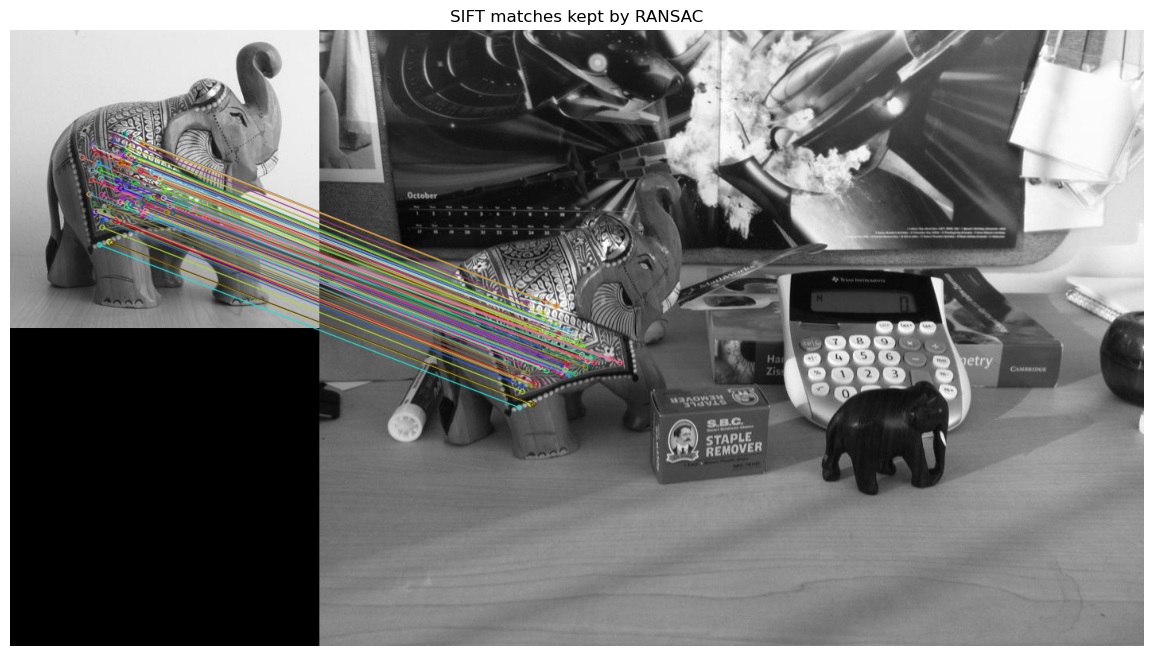

In [124]:
# Visualize matches (optional)
match_vis = cv2.drawMatches(
    box_image, kp1,
    scene_image, kp2,
    good_matches, None,
    matchesMask=mask.ravel().tolist(),
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

plt.figure(figsize=(16, 8))
plt.imshow(match_vis)
plt.title('SIFT matches kept by RANSAC')
plt.axis('off')
plt.show()


Detected polygon points on clutteredDesk.jpg:
[[175.57 539.01]
 [167.55 313.04]
 [340.67 278.01]
 [379.42 244.49]
 [407.81 258.  ]
 [413.67 203.39]
 [470.36 205.91]
 [475.98 256.31]
 [459.97 258.37]
 [471.18 353.19]
 [447.67 393.46]
 [416.56 401.26]
 [455.94 494.94]
 [380.2  511.44]
 [370.15 468.5 ]
 [335.25 528.72]
 [245.44 547.1 ]
 [235.59 531.9 ]
 [173.1  537.8 ]]


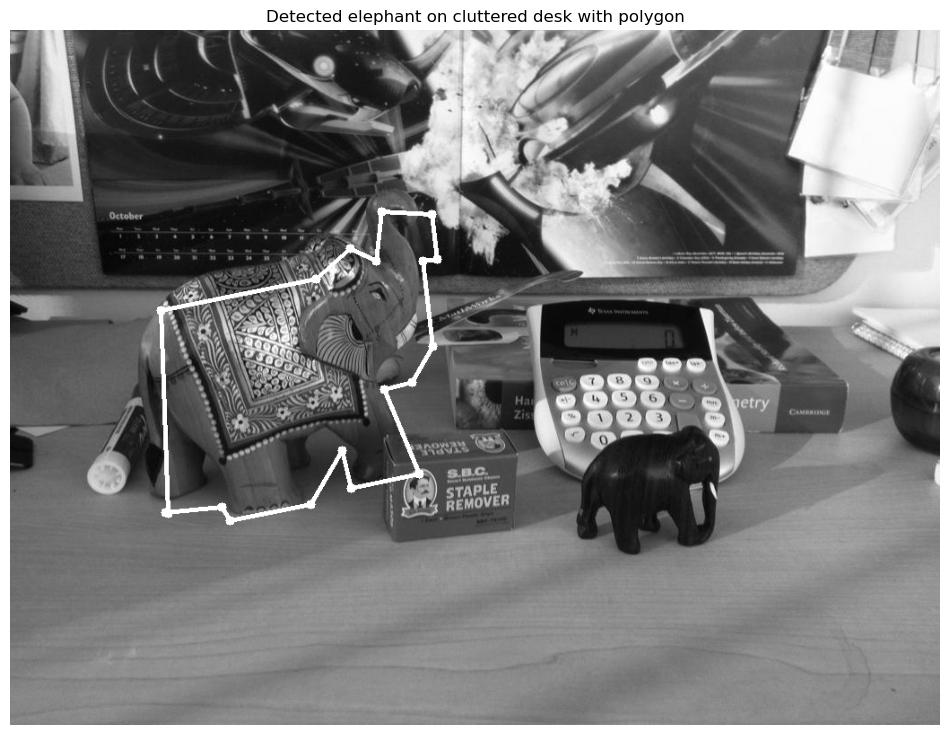

In [125]:
# Transform the elephant polyline to the desk image
poly_src = elephant_poly.reshape(-1, 1, 2).astype(np.float32)
poly_dst = cv2.perspectiveTransform(poly_src, H)
poly_dst_closed = np.vstack([poly_dst[:, 0, :], poly_dst[0, 0, :]])

print('\nDetected polygon points on clutteredDesk.jpg:')
print(np.round(poly_dst[:, 0, :], 2))

# Draw the detected elephant on the scene
final_vis = scene_image.copy()
pts = np.round(poly_dst_closed).astype(np.int32).reshape(-1, 1, 2)

# Draw the polyline
cv2.polylines(final_vis, [pts], isClosed=False, color=(255, 0, 0), thickness=3)

# Draw circles at each point for better visibility
for p in pts[:, 0, :]:
    cv2.circle(final_vis, tuple(p), 5, (255, 0, 0), -1)

plt.figure(figsize=(12, 10))
plt.imshow(final_vis, cmap='gray')
plt.title('Detected elephant on cluttered desk with polygon')
plt.axis('off')
plt.show()

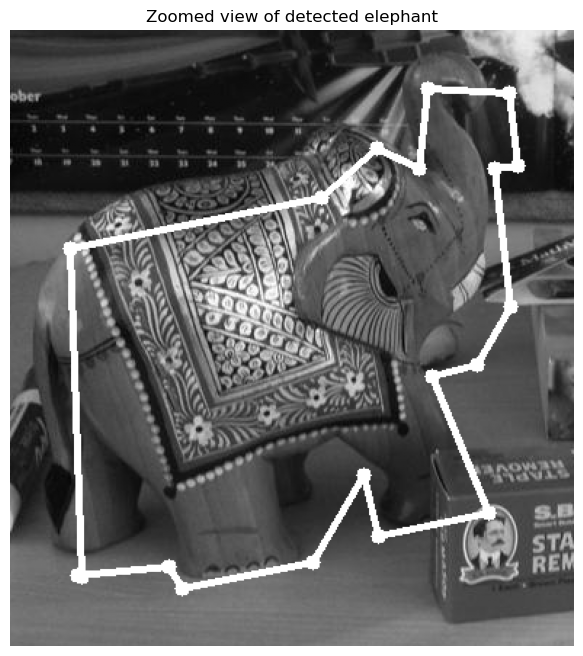

Summary:
Successfully detected elephant with 153 good matches
Polyline drawn using 19 points from the template
The white polyline shows the detected elephant shape in the scene


In [126]:
# Create a zoomed view of the detected area for better visualization
x_min = int(np.min(poly_dst[:, 0, 0])) - 40
x_max = int(np.max(poly_dst[:, 0, 0])) + 40
y_min = int(np.min(poly_dst[:, 0, 1])) - 40
y_max = int(np.max(poly_dst[:, 0, 1])) + 40

# Ensure coordinates are within image bounds
x_min = max(0, x_min)
x_max = min(scene_image.shape[1], x_max)
y_min = max(0, y_min)
y_max = min(scene_image.shape[0], y_max)

if x_max > x_min and y_max > y_min:
    zoomed_vis = final_vis[y_min:y_max, x_min:x_max]
    plt.figure(figsize=(10, 8))
    plt.imshow(zoomed_vis, cmap='gray')
    plt.title('Zoomed view of detected elephant')
    plt.axis('off')
    plt.show()


print('Summary:')
print('='*10)
print(f'Successfully detected elephant with {len(good_matches)} good matches')
print(f'Polyline drawn using {len(elephant_poly)} points from the template')
print('The white polyline shows the detected elephant shape in the scene')